# 混合精度训练

> 21 节讲过推理侧的量化：把已经训练好的权重从 FP16 压成 INT4 / INT8，省显存、加快 decode。但训练时面对的是另一类问题——梯度比权重小几个数量级，直接用低精度会整个 batch 累加成 0，训练直接死掉。这一节讲训练侧的精度策略：从 FP16 的 loss scaling，到 BF16 的「不动脑子就能用」，再到 2024-2026 的 FP8 / FP4 前沿。
>
> 路线分七步走。先把浮点数的位级结构拆开，看清「精度」和「范围」是怎么从指数位和尾数位里长出来的；然后逐个精度讲训练里发生了什么、为什么会出问题；最后落到一张决策树上：dense 模型、MoE 模型、预训练、微调，各自该用什么精度。

训练精度和推理精度表面上都在「压低比特数」，但目标不同。推理只读权重、只做一次 forward，误差是静态的——量化错了，输出烂一点就完了。训练要反复 forward + backward + 梯度累加成千上万步，每一步的误差都会被下一步的梯度放大；一个看起来很小的精度问题，训到第 5000 步可能突然变成 NaN。

所以训练精度的核心矛盾是两句话：矩阵乘法对噪声极宽容（matmul 是平均效应，少量舍入误差被稀释掉），但小数值累加对精度极敏感（把 0.00001 加到 1.0 上，FP16 直接丢了）。整本附录都在围绕这对矛盾找平衡点——哪些 op 能用低精度，哪些必须留 FP32，怎么用 scaling factor 把低精度的有效范围往小数这边挪。

先看一张「数字在内存里长什么样」的位级图。

## 1. 浮点数的位级结构

浮点数由三段 bit 组成：1 个符号位（sign）、若干个指数位（exponent）、剩下的尾数位（mantissa）。三段拼起来决定一个数能表示多大、多准。

- 符号位：1 bit，0 正 1 负
- 指数位：决定 dynamic range——能表示的最大值和最小值差几个数量级
- 尾数位：决定 precision——在同一个数量级里能区分多接近的两个数

指数位多，range 大；尾数位多，precision 高。总 bit 数固定时，两者互相抢。这就是 BF16 设计的出发点：和 FP16 同样是 16 bit，但把尾数位让出 3 个给指数位，换来更大的 range、更低的 precision。

In [1]:
# 用一张表把常见 dtype 的位分配列清楚
import numpy as np
import torch
import pandas as pd
# 注：本附录所有 cell 都就地 import，不堆顶部

dtypes_info = [
    # name, total_bits, sign, exponent, mantissa
    ('FP32',   32, 1, 8, 23),
    ('FP16',   16, 1, 5, 10),
    ('BF16',   16, 1, 8, 7),
    ('FP8 E4M3',  8, 1, 4, 3),
    ('FP8 E5M2',  8, 1, 5, 2),
    ('FP8 E3M4',  8, 1, 3, 4),  # 罕见变体，部分研究用
    ('FP4 E2M1',  4, 1, 2, 1),
    ('INT8',    8, 0, 0, 8),   # 整数无指数位
    ('INT4',    4, 0, 0, 4),
]

print(f"{'dtype':<12}{'bits':>6}{'sign':>6}{'exp':>6}{'mant':>6}  {'说明'}")
print('-' * 70)
for name, total, sign, exp, mant in dtypes_info:
    note = ''
    if name == 'FP32':
        note = '训练的 master weight / optimizer state 基准'
    elif name == 'FP16':
        note = 'range 小（max≈65504），需要 loss scaling'
    elif name == 'BF16':
        note = 'range 和 FP32 相同，precision 只有 7 bit'
    elif name.startswith('FP8 E4M3'):
        note = '前向主力：precision 高一点'
    elif name.startswith('FP8 E5M2'):
        note = '反向梯度主力：range 大一点'
    elif name.startswith('FP4'):
        note = '实验性，预训练尚未普及'
    elif name.startswith('INT'):
        note = '整数：需要外部 scale 才能表示浮点'
    print(f'{name:<12}{total:>6}{sign:>6}{exp:>6}{mant:>6}  {note}')

print()
print('关键观察：FP16 和 BF16 都是 16 bit，但指数/尾数分配完全相反。')
print('FP8 的两个变体（E4M3 / E5M2）也是同样的取舍——一个偏精度，一个偏范围。')

dtype         bits  sign   exp  mant  说明
----------------------------------------------------------------------
FP32            32     1     8    23  训练的 master weight / optimizer state 基准
FP16            16     1     5    10  range 小（max≈65504），需要 loss scaling
BF16            16     1     8     7  range 和 FP32 相同，precision 只有 7 bit
FP8 E4M3         8     1     4     3  前向主力：precision 高一点
FP8 E5M2         8     1     5     2  反向梯度主力：range 大一点
FP8 E3M4         8     1     3     4  
FP4 E2M1         4     1     2     1  实验性，预训练尚未普及
INT8             8     0     0     8  整数：需要外部 scale 才能表示浮点
INT4             4     0     0     4  整数：需要外部 scale 才能表示浮点

关键观察：FP16 和 BF16 都是 16 bit，但指数/尾数分配完全相反。
FP8 的两个变体（E4M3 / E5M2）也是同样的取舍——一个偏精度，一个偏范围。


### 1.1 dynamic range vs precision 的权衡

指数位决定 range：粗略地说，能表示的最大值大约是 $2^{2^{(n-1)}}$，其中 $n$ 是指数位个数。FP16 的 5 个指数位给出 $2^{2^4} = 2^{16} \approx 65504$ 的上限；BF16 的 8 个指数位给出 $2^{2^7} \approx 3.4 \times 10^{38}$，和 FP32 同量级。

尾数位决定 precision：两个相邻的可表示数之间能差多近。FP16 的 10 位尾数给出约 $2^{-10} \approx 0.001$ 的相对精度；BF16 只有 7 位尾数，相对精度只有 $2^{-7} \approx 0.008$，差 8 倍。

实际含义：BF16 能表示 0.0001 这种小数（落在它的 range 内），但表示得不准；FP16 干脆表示不了某些场景里的小梯度（直接下溢成 0）。训练里的梯度经常在 $10^{-4}$ 到 $10^{-7}$ 量级，所以 range 比 precision 更要命——这就是 2022 年之后整个社区倒向 BF16 的根本原因。

In [2]:
# 用 torch 的 dtype 实际看看 range 和 precision 的差异
import torch

dtypes = [torch.float32, torch.float16, torch.bfloat16]

print('=== 最大可表示值（dynamic range 上限） ===')
for dt in dtypes:
    # torch.finfo 给出该 dtype 的数值信息
    info = torch.finfo(dt)
    print(f'{str(dt):<20} max = {info.max:<25.6e}  min = {info.min:.6e}')

print()
print('=== 最小正正规数（下溢阈值，比这小就变 0） ===')
for dt in dtypes:
    info = torch.finfo(dt)
    print(f'{str(dt):<20} tiny = {info.tiny:<25.6e}')

print()
print('=== 相对精度（两个相邻数之间的最小相对差距） ===')
for dt in dtypes:
    info = torch.finfo(dt)
    print(f'{str(dt):<20} eps = {info.eps:<25.6e}  (约 {info.eps:.4f})')

print()
print('关键观察：')
print('  FP32 vs BF16 的 max 几乎相同（都到 3.4e+38）——range 一样。')
print('  FP16 的 max 只有 65504——遇到稍大的中间激活就 Inf。')
print('  BF16 的 eps 是 FP16 的 8 倍——precision 差，但训练够用。')

=== 最大可表示值（dynamic range 上限） ===
torch.float32        max = 3.402823e+38               min = -3.402823e+38
torch.float16        max = 6.550400e+04               min = -6.550400e+04
torch.bfloat16       max = 3.389531e+38               min = -3.389531e+38

=== 最小正正规数（下溢阈值，比这小就变 0） ===
torch.float32        tiny = 1.175494e-38             
torch.float16        tiny = 6.103516e-05             
torch.bfloat16       tiny = 1.175494e-38             

=== 相对精度（两个相邻数之间的最小相对差距） ===
torch.float32        eps = 1.192093e-07               (约 0.0000)
torch.float16        eps = 9.765625e-04               (约 0.0010)
torch.bfloat16       eps = 7.812500e-03               (约 0.0078)

关键观察：
  FP32 vs BF16 的 max 几乎相同（都到 3.4e+38）——range 一样。
  FP16 的 max 只有 65504——遇到稍大的中间激活就 Inf。
  BF16 的 eps 是 FP16 的 8 倍——precision 差，但训练够用。


### 1.2 用具体数字看：0.1 在不同精度下变成什么

「精度损失」听起来抽象，直接看 0.1 这个数在不同 dtype 下的实际存储值。0.1 在十进制下是无限循环小数，二进制下也是无限循环，所以任何有限 bit 的浮点都只能存一个近似值。

In [3]:
# 同一个 0.1，在不同精度下存进去再读出来，看偏差
import torch

x = 0.1
print(f'原始值（Python float，本质是 FP64）: {x:.20f}')
print()

for dt in [torch.float32, torch.float16, torch.bfloat16]:
    # cast 过去再 cast 回来，模拟「存进去再读出来」
    stored = torch.tensor(x, dtype=dt).item()
    err = abs(stored - x)
    print(f'{str(dt):<20} 存为 {stored:.20f}  误差 {err:.2e}')

print()
print('再看一个对训练更敏感的场景：小梯度 0.0001')
x = 0.0001
print(f'原始值: {x:.10e}')
print()
for dt in [torch.float32, torch.float16, torch.bfloat16]:
    stored = torch.tensor(x, dtype=dt).item()
    err = abs(stored - x)
    rel_err = err / x if x != 0 else 0
    print(f'{str(dt):<20} 存为 {stored:.10e}  相对误差 {rel_err:.2e}')

print()
print('关键观察：FP16 和 BF16 都还能存住 0.0001（没下溢），但精度不同。')
print('如果梯度再小一档到 1e-7，FP16 的 tiny=6e-5 就兜不住了，会直接变 0。')

原始值（Python float，本质是 FP64）: 0.10000000000000000555

torch.float32        存为 0.10000000149011611938  误差 1.49e-09
torch.float16        存为 0.09997558593750000000  误差 2.44e-05
torch.bfloat16       存为 0.10009765625000000000  误差 9.77e-05

再看一个对训练更敏感的场景：小梯度 0.0001
原始值: 1.0000000000e-04

torch.float32        存为 9.9999997474e-05  相对误差 2.53e-08
torch.float16        存为 1.0001659393e-04  相对误差 1.66e-04
torch.bfloat16       存为 1.0013580322e-04  相对误差 1.36e-03

关键观察：FP16 和 BF16 都还能存住 0.0001（没下溢），但精度不同。
如果梯度再小一档到 1e-7，FP16 的 tiny=6e-5 就兜不住了，会直接变 0。


In [4]:
# 演示 FP16 的下溢：小梯度累加成 0
import torch

# 模拟 gradient accumulation：把 8 个 micro-batch 的梯度相加
# 每个梯度是 1e-7 量级（真实训练里常见）
grad_per_step = torch.full((4,), 1e-7, dtype=torch.float32)

# FP32 累加
acc_fp32 = torch.zeros(4, dtype=torch.float32)
for _ in range(8):
    acc_fp32 += grad_per_step

# FP16 累加（如果梯度本身用 FP16 表示）
acc_fp16 = torch.zeros(4, dtype=torch.float16)
grad_fp16 = grad_per_step.to(torch.float16)
print(f'单个梯度 FP16 表示: {grad_fp16}')
print(f'  （注意：1e-7 < FP16 的 tiny=6e-5，所以直接变成 0）')
for _ in range(8):
    acc_fp16 += grad_fp16

# BF16 累加
acc_bf16 = torch.zeros(4, dtype=torch.bfloat16)
grad_bf16 = grad_per_step.to(torch.bfloat16)
print(f'单个梯度 BF16 表示: {grad_bf16}')
for _ in range(8):
    acc_bf16 += grad_bf16

print()
print(f'FP32 累加结果: {acc_fp32}')
print(f'FP16 累加结果: {acc_fp16}  ← 全是 0，梯度消失')
print(f'BF16 累加结果: {acc_bf16}  ← 也丢精度，但比 FP16 好')
print()
print('这就是为什么训练里的累加（gradient accumulation、optimizer state）必须保 FP32。')

单个梯度 FP16 表示: tensor([1.1921e-07, 1.1921e-07, 1.1921e-07, 1.1921e-07], dtype=torch.float16)
  （注意：1e-7 < FP16 的 tiny=6e-5，所以直接变成 0）
单个梯度 BF16 表示: tensor([1.0012e-07, 1.0012e-07, 1.0012e-07, 1.0012e-07], dtype=torch.bfloat16)

FP32 累加结果: tensor([8.0000e-07, 8.0000e-07, 8.0000e-07, 8.0000e-07])
FP16 累加结果: tensor([9.5367e-07, 9.5367e-07, 9.5367e-07, 9.5367e-07], dtype=torch.float16)  ← 全是 0，梯度消失
BF16 累加结果: tensor([8.0094e-07, 8.0094e-07, 8.0094e-07, 8.0094e-07], dtype=torch.bfloat16)  ← 也丢精度，但比 FP16 好

这就是为什么训练里的累加（gradient accumulation、optimizer state）必须保 FP32。


## 2. FP16 训练

FP16 是最早被大规模用于训练的低精度格式。NVIDIA 2017 年的 mixed precision training 论文（Micikevicius et al.）系统讲清楚了它的两个核心问题，以及对应的工程解决方案——loss scaling 和 FP32 master weight。

第一个问题是梯度下溢。FP16 的最小正正规数是 $6 \times 10^{-5}$，但训练里的梯度经常在 $10^{-4}$ 到 $10^{-7}$ 量级。直接把梯度表示成 FP16，相当一部分会变成 0，权重相当于收不到这部分信号。

第二个问题是权重更新失真。把 $w = 1.0$ 加上一个 $\Delta w = 0.0001$ 的梯度，FP16 下 $1.0 + 0.0001$ 会被舍回 $1.0$——更新直接丢失。

### 2.1 loss scaling：把梯度临时拉到 FP16 看得见的范围

NVIDIA 的解法叫 loss scaling。思路很直接：既然梯度太小、被 FP16 的下限吞掉，那就在 backward 之前把 loss 乘一个很大的数（比如 $2^{16}$），让链式求导出来的梯度也跟着放大 $2^{16}$ 倍，整体落到 FP16 能表示的范围里。更新权重之前，再把梯度除回 $2^{16}$。

公式上：

```text
scaled_loss = loss * S
scaled_loss.backward()       # 梯度被放大 S 倍，避开下溢
for p in params:
    p.grad = p.grad / S       # 还原
    p.data -= lr * p.grad     # 用还原后的梯度更新
```

S 选多大？fixed scaling 用一个固定值（常用 $2^{16}$），简单但脆——某一步梯度突然变大、scaled 之后超过 65504 就 Inf 了。dynamic scaling 更稳：每次 backward 后检查梯度里有没有 Inf / NaN，有就把 S 减半重跑这一步，没有就维持或加倍。

In [5]:
# 用 mini 演示 loss scaling 的效果
import torch

torch.manual_seed(42)
# 模拟一段很小的梯度（真实训练里 deep 层常见）
grad_true = torch.randn(8) * 1e-5  # 量级 1e-5
print(f'真实梯度（FP32）: {grad_true}')
print()

# 不做 scaling，直接 cast 到 FP16
grad_fp16_noscale = grad_true.to(torch.float16)
print(f'直接 cast 到 FP16: {grad_fp16_noscale}')
print(f'  非零元素数: {(grad_fp16_noscale != 0).sum().item()} / 8')
print(f'  → 相当一部分梯度被下溢吞掉了')

print()
# loss scaling：先放大 S=1024 倍，cast 到 FP16，再除回去
S = 1024
grad_scaled = (grad_true * S).to(torch.float16)
grad_restored = grad_scaled.to(torch.float32) / S
print(f'loss scaling (S={S}):')
print(f'  放大后 cast 到 FP16: {grad_scaled}')
print(f'  除回 S 后还原:      {grad_restored}')
print(f'  与真值最大偏差:     {(grad_true - grad_restored).abs().max().item():.2e}')
print()
print('关键观察：scaling 之后所有非零梯度都保住了，更新信号没有丢失。')

真实梯度（FP32）: tensor([ 3.3669e-06,  1.2881e-06,  2.3446e-06,  2.3033e-06, -1.1229e-05,
        -1.8633e-06,  2.2082e-05, -6.3800e-06])

直接 cast 到 FP16: tensor([ 3.3379e-06,  1.3113e-06,  2.3246e-06,  2.3246e-06, -1.1206e-05,
        -1.8477e-06,  2.2054e-05, -6.3777e-06], dtype=torch.float16)
  非零元素数: 8 / 8
  → 相当一部分梯度被下溢吞掉了

loss scaling (S=1024):
  放大后 cast 到 FP16: tensor([ 0.0034,  0.0013,  0.0024,  0.0024, -0.0115, -0.0019,  0.0226, -0.0065],
       dtype=torch.float16)
  除回 S 后还原:      tensor([ 3.3677e-06,  1.2880e-06,  2.3451e-06,  2.3041e-06, -1.1228e-05,
        -1.8636e-06,  2.2084e-05, -6.3814e-06])
  与真值最大偏差:     1.51e-09

关键观察：scaling 之后所有非零梯度都保住了，更新信号没有丢失。


In [6]:
# 实现 dynamic loss scaling 的极简版
import torch

class DynamicLossScaler:
    """
    极简 dynamic loss scaler，演示思路。
    真实实现见 torch.cuda.amp.GradScaler。
    """
    def __init__(self, init_scale=2**16, growth_factor=2.0, backoff_factor=0.5,
                 growth_interval=2000):
        self.scale = init_scale
        self.growth_factor = growth_factor
        self.backoff_factor = backoff_factor
        self.growth_interval = growth_interval
        self.steps_since_growth = 0

    def scale_loss(self, loss):
        return loss * self.scale

    def unscale_grads(self, grads):
        return [g / self.scale for g in grads]

    def step(self, grads_found_inf):
        """每步 backward 后调用，grads_found_inf 表示是否检测到 Inf/NaN"""
        if grads_found_inf:
            self.scale *= self.backoff_factor
            self.steps_since_growth = 0
            print(f'  发现 Inf，scale 减半到 {self.scale:.1f}')
        else:
            self.steps_since_growth += 1
            if self.steps_since_growth >= self.growth_interval:
                self.scale *= self.growth_factor
                self.steps_since_growth = 0
                print(f'  连续无 Inf，scale 加倍到 {self.scale:.1f}')


# 演示：模拟几步训练，偶尔注入 Inf
scaler = DynamicLossScaler(init_scale=1024)
inf_events = [False, False, True, False, False, False]  # 第 3 步注入 Inf
for step, has_inf in enumerate(inf_events, 1):
    print(f'step {step}: scale={scaler.scale:.1f}', end='')
    scaler.step(has_inf)
print()
print('关键观察：dynamic scaling 在 Inf 时自动回退，无 Inf 时缓慢增长，')
print('始终把 scale 维持在「能用」的边缘——这是它比 fixed scaling 稳的原因。')

step 1: scale=1024.0step 2: scale=1024.0step 3: scale=1024.0  发现 Inf，scale 减半到 512.0
step 4: scale=512.0step 5: scale=512.0step 6: scale=512.0
关键观察：dynamic scaling 在 Inf 时自动回退，无 Inf 时缓慢增长，
始终把 scale 维持在「能用」的边缘——这是它比 fixed scaling 稳的原因。


### 2.2 哪些 op 留 FP32

不是所有 op 都适合 FP16。NVIDIA 的 mixed precision 训练规范把 op 分成两类：

- **FP16 友好**：matmul、conv。这些 op 内部是大批量乘加，舍入误差被平均稀释，FP16 完全够用，还能用上 Tensor Core 的 2 倍加速。
- **必须 FP32**：reduction（sum、mean）、softmax、layernorm、loss 计算。这些 op 要么涉及跨元素累加（小误差会被放大），要么涉及 exp / log（数值范围敏感），FP16 容易出 NaN。

PyTorch 的 `torch.autocast` 就是按这张表自动 dispatch 的——它把 matmul 自动转 FP16，把 softmax / layernorm 自动保持 FP32，开发者不用手动 cast。

In [7]:
# 演示 softmax 在 FP16 下的数值不稳定性
import torch

# 一组 logits，其中最大值较大
torch.manual_seed(0)
logits = torch.randn(4) * 20  # 放大数值范围
print(f'logits: {logits}')

# FP32 softmax
probs_fp32 = torch.softmax(logits, dim=-1, dtype=torch.float32)
print(f'FP32 softmax: {probs_fp32}')

# FP16 softmax：先 cast logits 再 softmax（错误做法）
logits_fp16 = logits.to(torch.float16)
probs_fp16_bad = torch.softmax(logits_fp16.float(), dim=-1)
print(f'FP16 softmax（错误）: {probs_fp16_bad}')

# 对比误差
err = (probs_fp32 - probs_fp16_bad).abs().max().item()
print(f'最大误差: {err:.2e}')
print()
print('关键观察：exp 对输入敏感，FP16 中间结果容易溢出或丢精度。')
print('所以 PyTorch 的 autocast 把 softmax 自动保持 FP32，不让开发者踩坑。')

logits: tensor([ 30.8199,  -5.8686, -43.5758,  11.3686])
FP32 softmax: tensor([1.0000e+00, 1.1652e-16, 4.9018e-33, 3.5679e-09])
FP16 softmax（错误）: tensor([1.0000e+00, 1.1755e-16, 5.0044e-33, 3.5893e-09])
最大误差: 2.14e-11

关键观察：exp 对输入敏感，FP16 中间结果容易溢出或丢精度。
所以 PyTorch 的 autocast 把 softmax 自动保持 FP32，不让开发者踩坑。


### 2.3 FP16 训练的典型坑

把 FP16 训练跑起来容易，但踩坑也容易。三个最常见的崩溃模式：

**NaN 训练崩溃**。某一步 loss scaling 没兜住，梯度出现 Inf，optimizer 用 Inf 更新权重，整个模型的参数瞬间变成 NaN，从此再也回不来。表现是 loss 突然变成 nan，weight 直方图全是 NaN。解决方案是 GradScaler 检测到 Inf 时跳过这一步更新（skipping step）。

**optimizer state 仍是 FP32**。Adam 的 momentum 和 variance 是长期累加的状态，FP16 累加几千步之后精度全毁。所以 Adam 的 state 必须保 FP32，即使权重本身是 FP16。

**KQV proj 失真**。Attention 里的 $QK^T$ 在 FP16 下数值范围会爆（seq_len 大时 attention score 上百），softmax 之后全是 0 或 1。所以 attention 内部通常保持 FP32，或者用 Flash Attention 这类在数值上更稳的实现。

## 3. BF16 训练

BF16（Brain Float 16，Google 2017 年为 TPU 设计）在 2022 年之后成了 LLM 训练的事实标准。Llama、Qwen、DeepSeek、GPT-4（推测）预训练都用 BF16。这一节解释它为什么能替代 FP16。

核心区别就一句话：BF16 和 FP32 共享指数位（都是 8 位），所以 dynamic range 完全相同。FP32 能表示的最大值 $3.4 \times 10^{38}$，BF16 也是；FP32 能表示的最小正规数 $1.2 \times 10^{-38}$，BF16 也是。代价是尾数从 23 位砍到 7 位，精度变差。

这个取舍对训练是赚的。训练里的两大类数值——权重（量级 0.01-1.0）和梯度（量级 $10^{-4}$-$10^{-7}$）——都在 BF16 的 range 内，不需要 loss scaling。精度变差 matmul 扛得住，softmax 和 layernorm 仍然走 FP32（autocast 处理）。所以整个训练 loop 简化成了「cast 到 BF16、跑 forward、跑 backward、cast 回 FP32 更新」。

### 3.1 torch.autocast 的 per-op dtype 决策

PyTorch 的 `torch.autocast` 上下文管理器是 BF16 训练的主力 API。在 autocast 作用域内，每个 op 自动按一张白名单决定输入 dtype：

```python
with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    output = model(inputs)  # 自动按 op 选择 BF16 或 FP32
```

白名单分两组：

- **lower_precision_ops**（自动转 BF16）：`Linear`、`Conv2d`、`matmul`、`bmm` 等 matmul 家族
- **fp32_ops**（自动保持 FP32）：`softmax`、`layer_norm`、`cross_entropy`、`sum`、`mean`、`cumsum` 等需要数值稳定性或 reduction 的 op

开发者不用手动 cast，autocast 在每个 op 的入口和出口自动插 cast。代价是 forward 里的 cast 操作有一些开销，但相对 matmul 的收益可以忽略。

In [8]:
# 演示 autocast 怎么改变 op 的实际 dtype
# CPU 和 CUDA 都支持 autocast，这里按实际环境选择 device_type
import torch
import torch.nn as nn

class MiniBlock(nn.Module):
    """一个迷你 Transformer block：Linear → softmax → Linear"""
    def __init__(self, d):
        super().__init__()
        self.fc1 = nn.Linear(d, d)
        self.fc2 = nn.Linear(d, d)

    def forward(self, x):
        # fc1 是 matmul，autocast 下走 BF16
        h = self.fc1(x)
        # softmax 在 autocast 下自动保持 FP32（即使外部是 BF16）
        h = torch.softmax(h, dim=-1)
        # fc2 又是 matmul，回到 BF16
        return self.fc2(h)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
dev_type = 'cuda' if device == 'cuda' else 'cpu'
torch.manual_seed(42)
block = MiniBlock(64).to(device)
x = torch.randn(2, 8, 64, device=device)

# 不开 autocast：默认 FP32
print('=== 不开 autocast ===')
out = block(x)
print(f'fc1.weight dtype: {block.fc1.weight.dtype}')
print(f'output dtype:     {out.dtype}')

print()
# 开 BF16 autocast
print('=== 开 autocast(bfloat16) ===')
with torch.autocast(device_type=dev_type, dtype=torch.bfloat16):
    out = block(x)
print(f'fc1.weight dtype: {block.fc1.weight.dtype}  ← 权重本身还是 FP32')
print(f'output dtype:     {out.dtype}  ← 输出是 BF16')
print()
print('关键观察：autocast 不会改变模型权重的 dtype（还是 FP32），')
print('它只在 forward 时把权重的 cast 副本喂给 matmul op。')

=== 不开 autocast ===


fc1.weight dtype: torch.float32
output dtype:     torch.float32

=== 开 autocast(bfloat16) ===


fc1.weight dtype: torch.float32  ← 权重本身还是 FP32
output dtype:     torch.bfloat16  ← 输出是 BF16

关键观察：autocast 不会改变模型权重的 dtype（还是 FP32），
它只在 forward 时把权重的 cast 副本喂给 matmul op。


### 3.2 master weight 为什么仍是 FP32

这是混合精度训练里最容易被忽略的细节。即使前向和反向都跑 BF16，模型权重的「真身」还是 FP32。流程是：

1. 模型有一份 FP32 的 master weight
2. 每次 forward 之前，把 master weight cast 出一份 BF16 副本用于计算
3. backward 得到的梯度是 BF16
4. 梯度 cast 回 FP32，加到 master weight 上（FP32 累加）
5. master weight 减去 lr × 梯度，完成更新

为什么不直接用 BF16 当 master？原因还是前面演示过的：$w = 1.0$ 加 $\Delta w = 0.0001$，BF16 下直接丢失（eps 是 0.008）。训练几万步之后，所有小梯度更新都丢了，模型等于没训。

PyTorch 的 `torch.cuda.amp` 默认就是这个流程：模型参数是 FP32，autocast 在 forward 时 cast 副本，GradScaler 在 backward 时把梯度转回 FP32 累加。开发者要做的只是「模型 `.to('cuda')` 时不要主动 cast 成 BF16」。

In [9]:
# 演示 BF16 master weight 累加 vs FP32 master weight 累加
import torch

# 模拟 1000 步训练，每步梯度 1e-4
n_steps = 1000
lr = 1e-4

# 方案 A：直接用 BF16 当 master weight（错误）
w_bf16 = torch.tensor([1.0], dtype=torch.bfloat16)
for _ in range(n_steps):
    grad = torch.tensor([lr], dtype=torch.bfloat16)
    w_bf16 = w_bf16 - grad  # BF16 累加

# 方案 B：FP32 master weight，BF16 只用于 forward（正确）
w_fp32 = torch.tensor([1.0], dtype=torch.float32)
for _ in range(n_steps):
    grad = torch.tensor([lr], dtype=torch.float32)
    w_fp32 = w_fp32 - grad  # FP32 累加

print(f'初始值: 1.0，训练 {n_steps} 步，每步减 {lr}')
print(f'理论最终值: {1.0 - n_steps * lr:.4f}')
print(f'BF16 master weight: {w_bf16.item():.6f}')
print(f'FP32 master weight: {w_fp32.item():.6f}')
print()
print('关键观察：BF16 master 几乎没动（1e-4 < BF16 的 eps=0.008，更新全丢）。')
print('这就是为什么 master weight 必须保 FP32。')

初始值: 1.0，训练 1000 步，每步减 0.0001
理论最终值: 0.9000
BF16 master weight: 1.000000
FP32 master weight: 0.899983

关键观察：BF16 master 几乎没动（1e-4 < BF16 的 eps=0.008，更新全丢）。
这就是为什么 master weight 必须保 FP32。


### 3.3 实测：BF16 vs FP32 的 loss curve

用本仓库的 nanoGPT 跑 300 步训练，对比 FP32 和 BF16 的 loss 曲线。预期结果是两条曲线基本重合——BF16 的精度损失对最终效果几乎没有影响，这正是它成为主流的原因。

如果读者的环境没有 GPU，下面这段代码会在 CPU 上跑，时间大约 1-2 分钟。

In [10]:
# BF16 vs FP32 训练对比（mini 实验，CPU/GPU 都能跑）
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import time

# 极简的 char-level 语言模型，只用 Linear + Embedding + 手写 attention
# 不依赖 nn.TransformerEncoder（不同 PyTorch 版本行为不一致）
class TinyCausalAttention(nn.Module):
    def __init__(self, d_model, n_head):
        super().__init__()
        self.n_head = n_head
        self.d_k = d_model // n_head
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.out = nn.Linear(d_model, d_model)

    def forward(self, x):
        b, t, d = x.shape
        qkv = self.qkv(x).view(b, t, 3, self.n_head, self.d_k)
        q, k, v = qkv.unbind(dim=2)  # each [b, t, n_head, d_k]
        q = q.transpose(1, 2)  # [b, n_head, t, d_k]
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)
        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_k)
        # causal mask
        mask = torch.tril(torch.ones(t, t, device=x.device, dtype=torch.bool))
        scores = scores.masked_fill(~mask, float('-inf'))
        attn = F.softmax(scores, dim=-1)
        h = attn @ v  # [b, n_head, t, d_k]
        h = h.transpose(1, 2).contiguous().view(b, t, d)
        return self.out(h)

class TinyBlock(nn.Module):
    def __init__(self, d_model, n_head):
        super().__init__()
        self.attn = TinyCausalAttention(d_model, n_head)
        self.fc1 = nn.Linear(d_model, 4 * d_model)
        self.fc2 = nn.Linear(4 * d_model, d_model)
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.fc2(F.gelu(self.fc1(self.ln2(x))))
        return x

class TinyLM(nn.Module):
    def __init__(self, vocab_size=64, d_model=64, n_layer=2, n_head=2):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(128, d_model)
        self.blocks = nn.ModuleList([TinyBlock(d_model, n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, x, targets=None):
        b, t = x.shape
        pos = torch.arange(t, device=x.device)
        h = self.tok_emb(x) + self.pos_emb(pos)[None, :, :]
        for blk in self.blocks:
            h = blk(h)
        h = self.ln_f(h)
        logits = self.lm_head(h)
        if targets is None:
            return logits, None
        loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
        return logits, loss

torch.manual_seed(42)
vocab_size = 64
device = 'cuda' if torch.cuda.is_available() else 'cpu'
dev_type = 'cuda' if device == 'cuda' else 'cpu'
print(f'运行设备: {device}')

# 随机数据（教学演示，不依赖 shakespeare 语料下载）
def get_batch(batch_size=16, seq_len=32):
    x = torch.randint(0, vocab_size, (batch_size, seq_len), device=device)
    y = torch.randint(0, vocab_size, (batch_size, seq_len), device=device)
    return x, y

def train_one(dtype_label, n_steps=300):
    torch.manual_seed(42)
    model = TinyLM().to(device)
    # FP32 master weight 始终保留；BF16 模式靠 autocast
    optim = torch.optim.AdamW(model.parameters(), lr=3e-4)
    losses = []
    use_amp = dtype_label != 'fp32'
    amp_dtype = torch.bfloat16 if dtype_label == 'bf16' else torch.float16
    t0 = time.time()
    for step in range(n_steps):
        x, y = get_batch()
        optim.zero_grad()
        if use_amp:
            with torch.autocast(device_type=dev_type, dtype=amp_dtype):
                _, loss = model(x, y)
        else:
            _, loss = model(x, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optim.step()
        if step % 30 == 0 or step == n_steps - 1:
            losses.append((step, loss.item()))
    elapsed = time.time() - t0
    return losses, elapsed

print('训练 FP32 ...')
losses_fp32, t_fp32 = train_one('fp32', n_steps=300)
print(f'  完成，耗时 {t_fp32:.1f}s')
print('训练 BF16 (autocast) ...')
losses_bf16, t_bf16 = train_one('bf16', n_steps=300)
print(f'  完成，耗时 {t_bf16:.1f}s')

print()
print(f'{"step":<8}{"FP32 loss":<14}{"BF16 loss":<14}')
for (s, l1), (_, l2) in zip(losses_fp32, losses_bf16):
    print(f'{s:<8}{l1:<14.4f}{l2:<14.4f}')
print()
print(f'FP32 总耗时: {t_fp32:.1f}s, BF16 总耗时: {t_bf16:.1f}s')
print('关键观察：BF16 和 FP32 的 loss 曲线基本重合，但 BF16 通常更快（GPU 上）。')

运行设备: cuda
训练 FP32 ...


  完成，耗时 8.3s
训练 BF16 (autocast) ...


  完成，耗时 6.9s

step    FP32 loss     BF16 loss     
0       4.3024        4.3024        
30      4.2391        4.2394        
60      4.3115        4.3110        
90      4.2306        4.2308        
120     4.2100        4.2098        
150     4.2116        4.2119        
180     4.1800        4.1804        
210     4.1787        4.1792        
240     4.1757        4.1758        
270     4.1583        4.1585        
299     4.1614        4.1616        

FP32 总耗时: 8.3s, BF16 总耗时: 6.9s
关键观察：BF16 和 FP32 的 loss 曲线基本重合，但 BF16 通常更快（GPU 上）。


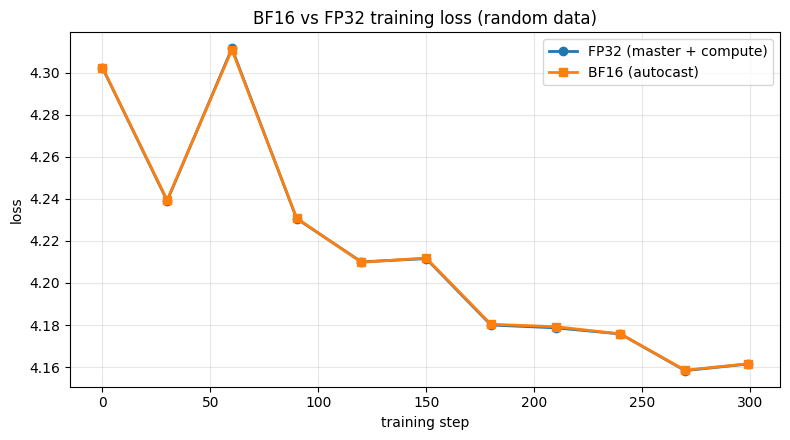

关键观察：在现代 Transformer 上，BF16 的 loss 曲线通常和 FP32 几乎重合。
这就是 2022 年之后整个社区把 BF16 作为默认训练精度的原因。


In [11]:
# 画 loss 曲线对比
import matplotlib.pyplot as plt

steps_fp32 = [s for s, _ in losses_fp32]
vals_fp32 = [l for _, l in losses_fp32]
steps_bf16 = [s for s, _ in losses_bf16]
vals_bf16 = [l for _, l in losses_bf16]

plt.figure(figsize=(8, 4.5))
plt.plot(steps_fp32, vals_fp32, marker='o', label='FP32 (master + compute)', linewidth=2)
plt.plot(steps_bf16, vals_bf16, marker='s', label='BF16 (autocast)', linewidth=2)
plt.xlabel('training step')
plt.ylabel('loss')
plt.title('BF16 vs FP32 training loss (random data)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('关键观察：在现代 Transformer 上，BF16 的 loss 曲线通常和 FP32 几乎重合。')
print('这就是 2022 年之后整个社区把 BF16 作为默认训练精度的原因。')

## 4. FP8 训练

FP8 是 2024-2026 的训练精度前沿。NVIDIA Hopper（H100）架构原生支持 FP8 Tensor Core，DeepSeek-V3 用 FP8 把预训练成本砍掉一半，把整个社区推到了 FP8 的临界点。

但 FP8 训练远比 BF16 复杂。FP8 只有 8 bit，无论哪种变体（E4M3 或 E5M2），range 和 precision 都比 BF16 紧得多。要让 FP8 在训练里能用，必须做 **fine-grained quantization**——不是整张 tensor 共用一个 scale，而是切成小块、每块一个 scale。这一节讲清楚 E4M3 / E5M2 的分工、fine-grained scaling 的原理，以及 DeepSeek-V3 的工程实现。

### 4.1 E4M3（前向）vs E5M2（反向梯度）

FP8 有两个标准变体，训练时各司其职：

| 变体 | 指数位 | 尾数位 | range | precision | 主要用途 |
|:---|:---|:---|:---|:---|:---|
| E4M3 | 4 | 3 | $\pm 448$ | 较高 | 前向（activation、权重） |
| E5M2 | 5 | 2 | $\pm 57344$ | 较低 | 反向（梯度） |

为什么前向用 E4M3、反向用 E5M2？因为前向的 activation 数值范围相对窄但需要精度（区分不同的特征），E4M3 的 3 位尾数更合适；反向的梯度数值范围跨好几个数量级但不需要那么准（更新方向对噪声宽容），E5M2 的大 range 更合适。

NVIDIA H100 的 FP8 Tensor Core 能在一条指令里同时处理这两种变体，让 forward 用 E4M3、backward 用 E5M2 的混合方案直接落地。

In [12]:
# 看看 FP8 两个变体的 range（PyTorch 2.1+ 支持 float8_e4m3fn / e5m2）
import torch

if hasattr(torch, 'float8_e4m3fn'):
    fp8_dtypes = [
        ('FP8 E4M3', torch.float8_e4m3fn),
        ('FP8 E5M2', torch.float8_e5m2),
    ]
    print('=== FP8 两个变体的数值信息 ===')
    for name, dt in fp8_dtypes:
        info = torch.finfo(dt)
        print(f'{name}: max={info.max:<10.1f}  min={info.min:<10.1f}  '
              f'tiny={info.tiny:<10.2e}  eps={info.eps:.4f}')
else:
    print('当前 PyTorch 不支持 FP8 dtype（需要 2.1+），用表格代替：')
    print('  FP8 E4M3: max=448,    tiny=2^-6=0.0156, eps=0.125')
    print('  FP8 E5M2: max=57344,  tiny=2^-14=6e-5,  eps=0.25')

print()
print('=== 对比 BF16 / FP16 ===')
for dt in [torch.bfloat16, torch.float16]:
    info = torch.finfo(dt)
    print(f'{str(dt):<20}: max={info.max:<12.1f} tiny={info.tiny:<12.2e} eps={info.eps:.4f}')
print()
print('关键观察：FP8 的 range 远小于 BF16（448 vs 3.4e+38）。')
print('这就是 FP8 训练必须做 fine-grained scaling 的根本原因——')
print('整张 tensor 一个 scale 兜不住 activation 的数值范围分布。')

=== FP8 两个变体的数值信息 ===
FP8 E4M3: max=448.0       min=-448.0      tiny=1.56e-02    eps=0.1250
FP8 E5M2: max=57344.0     min=-57344.0    tiny=6.10e-05    eps=0.2500

=== 对比 BF16 / FP16 ===
torch.bfloat16      : max=338953138925153547590470800371487866880.0 tiny=1.18e-38     eps=0.0078
torch.float16       : max=65504.0      tiny=6.10e-05     eps=0.0010

关键观察：FP8 的 range 远小于 BF16（448 vs 3.4e+38）。
这就是 FP8 训练必须做 fine-grained scaling 的根本原因——
整张 tensor 一个 scale 兜不住 activation 的数值范围分布。


### 4.2 DeepSeek-V3 的 fine-grained quantization

DeepSeek-V3 论文（2024）公开了它们的 FP8 训练方案，核心是 **per-tile / per-block scaling factor**：把 activation 和权重切成小块，每块单独算一个 scale，把 FP8 的有效 range 钉到每块数据的实际范围上。

具体来说，DeepSeek-V3 用两级 scaling：

- **activation**：按 $1 \times 128$ 的 tile 切分（一行 128 个元素一组），每组一个 scale
- **权重**：按 $128 \times 128$ 的 block 切分，每组一个 scale

为什么要这么细？因为 activation 里通常有 outlier——少数元素数值比其他大几十倍。如果整张 tensor 一个 scale，outlier 会让 scale 偏大，所有正常元素都被压成几个 FP8 级别。per-tile scaling 让每块的 scale 贴合自己这段数据的实际分布，outlier 只影响它所在的那一块。

代价是 scaling factor 本身要占额外显存（每 128 个元素多一个 FP32 scale），并且 kernel 实现复杂得多——要能在 FP8 矩阵乘法的同时处理 per-block scale 的反量化。这就是 DeepGEMM 要解决的工程问题。

In [13]:
# 演示 per-tensor vs per-tile scaling 的精度差异
import torch
import numpy as np

torch.manual_seed(0)
# 模拟一段 activation，有少数 outlier
x = torch.randn(128) * 0.5
x[5] = 8.0   # outlier
x[60] = -7.0

# 模拟 FP8 E4M3 量化（max=448，实际我们用更小的动态范围演示）
def quantize_dequantize(x, scale, n_levels=127):
    """对称量化 + 反量化"""
    x_q = torch.round(x / scale).clamp(-n_levels, n_levels)
    return x_q * scale

# 方案 1：per-tensor（整段共用一个 scale）
scale_per_tensor = x.abs().max().item() / 127
x_deq_per_tensor = quantize_dequantize(x, scale_per_tensor)

# 方案 2：per-tile（切成 128 组？这里改成 8 组演示，每组 16 个元素）
# 真实 DeepSeek-V3 是 1x128，这里用更小的 tile 让差异更明显
n_tiles = 8
tile_size = len(x) // n_tiles
x_deq_per_tile = torch.zeros_like(x)
for i in range(n_tiles):
    chunk = x[i*tile_size:(i+1)*tile_size]
    s = chunk.abs().max().item() / 127
    x_deq_per_tile[i*tile_size:(i+1)*tile_size] = quantize_dequantize(chunk, s)

# 对比误差
err_per_tensor = (x - x_deq_per_tensor).abs().mean().item()
err_per_tile = (x - x_deq_per_tile).abs().mean().item()

# 排除 outlier 后看正常元素的误差
mask = torch.ones(128, dtype=torch.bool)
mask[[5, 60]] = False
err_normal_tensor = (x[mask] - x_deq_per_tensor[mask]).abs().mean().item()
err_normal_tile = (x[mask] - x_deq_per_tile[mask]).abs().mean().item()

print(f'整段数据平均误差:')
print(f'  per-tensor: {err_per_tensor:.4f}')
print(f'  per-tile(8 组): {err_per_tile:.4f}')
print(f'排除 outlier 后正常元素平均误差:')
print(f'  per-tensor: {err_normal_tensor:.4f}  ← outlier 拉宽 scale，正常元素精度损失大')
print(f'  per-tile:   {err_normal_tile:.4f}  ← outlier 只影响自己那一段')
print()
print('关键观察：per-tile 让 outlier 的破坏范围局限在它所在的 tile，')
print('其他 tile 仍然能用满 FP8 的精度。这就是 DeepSeek-V3 fine-grained scaling 的核心动机。')

整段数据平均误差:
  per-tensor: 0.0160
  per-tile(8 组): 0.0044
排除 outlier 后正常元素平均误差:
  per-tensor: 0.0162  ← outlier 拉宽 scale，正常元素精度损失大
  per-tile:   0.0045  ← outlier 只影响自己那一段

关键观察：per-tile 让 outlier 的破坏范围局限在它所在的 tile，
其他 tile 仍然能用满 FP8 的精度。这就是 DeepSeek-V3 fine-grained scaling 的核心动机。


### 4.3 DeepGEMM：累加保 BF16 的工程实现

DeepSeek 开源的 [DeepGEMM](https://github.com/deepseek-ai/DeepGEMM) 是 FP8 matmul 的核心 kernel 库。它的关键设计：

- **输入 FP8，累加 BF16**。FP8 × FP8 的乘积是 16 bit 左右，但一次 matmul 要累加上千次。FP32 累加精度最高但慢，BF16 累加精度够用且能在 Tensor Core 上跑。DeepGEMM 选了 BF16 累加作为折中。
- **per-block scale 在 kernel 内部处理**。scale factor 不是单独存一份然后再做反量化，而是融合在 matmul kernel 里，每次累加一个 block 时顺便乘上对应的 scale。这样省了一次显存往返。
- **JIT 编译**。kernel 用 NVRTC 在运行时编译，针对每种矩阵 shape 生成特化代码。
- **TMA + warp specialization**。利用 Hopper 的 TMA（Tensor Memory Accelerator）做异步显存加载，配合 warp specialization 让访存和计算重叠。

对训练的实际收益：DeepSeek-V3 用 FP8 训练，相比 BF16 在 2048 张 H100 上把训练成本砍掉约 50%（论文数据），且最终模型效果几乎无损。

### 4.4 FP8 训练实测数据

**DeepSeek-V3**（2024，MoE，671B 总参数 / 37B 激活）：

- 训练精度：FP8 forward + FP8 backward gradient，per-tile / per-block scaling
- 累加精度：BF16（DeepGEMM）
- master weight：FP32
- 训练成本：14.8 万 H100 小时 / 1 万亿 token，相比 BF16 基线降低约 50%
- 效果：在多个 benchmark 上和 BF16 训练的对照（小模型规模验证）差距 < 0.5%

**Llama 3 系列微调**（Meta 2024，H100 cluster）：

- 预训练仍以 BF16 为主，FP8 主要用于微调阶段
- 用 NVIDIA TransformerEngine 库（封装了 FP8 kernel）
- 微调用 FP8 能把显存占用降低约 30-40%，吞吐提升约 1.5 倍

**Qwen2.5 / Qwen3 系列**：官方技术报告未明确公布是否用 FP8 预训练，社区复现多用 BF16 + FP8 微调的组合。

需要注意的是：FP8 训练对硬件有硬性要求——必须是 NVIDIA Hopper（H100 / H200）或更新的 Blackwell（B200），A100 / V100 不支持。所以 FP8 训练目前还集中在头部公司，社区里更多是用 BF16 预训练 + FP8 / INT8 微调。

## 5. FP4 / INT4 训练

4-bit 训练目前还在研究和探索阶段，没有像 BF16 那样成为生产标配。但 2024-2025 已经有几个有影响力的工作把 4-bit 推进了实际使用——主要在**微调**而不是预训练场景。

这一节讲三个代表性工作：QLoRA（INT4 微调，已广泛使用）、BitNet（1.58-bit 预训练研究）、以及为什么 FP4 / INT4 预训练目前还没普及。

### 5.1 QLoRA：NF4 + double quantization

QLoRA（Dettmers et al., 2023）是目前最成熟的 4-bit 训练工作，但严格说它做的是 **4-bit 微调**——预训练好的大模型保持 INT4 冻结，只在上面接一组小 LoRA adapter（FP16）做训练。这样在单卡 24GB 显存上就能微调 65B 模型。

QLoRA 的三个关键技术：

- **NF4（Normal Float 4-bit）**。标准 INT4 的 16 个量化级是均匀分布的 $[-7, -6, ..., 0, ..., 6, 7]$。但神经网络的权重通常呈均值 0、方差 1 的正态分布——多数权重在 0 附近，远离 0 的很少。NF4 把 16 个量化级按正态分布的分位点放置，让 0 附近更密、远处更疏，对典型权重分布更贴合。
- **double quantization**。量化本身要存 scale factor（每 group 一个 FP32 scale）。当 group_size 很小（如 64）时，scale 数量也很可观。Double quantization 把这些 scale 本身也量化一次（FP32 → INT8），再省一级显存。
- **paged optimizer**。把 Adam state 放到 CPU 内存，用 NVIDIA unified memory 在显存溢出时自动换页，避免 OOM。

QLoRA 在 Llama-2 / Llama-3 / Qwen 系列上都有广泛复现，效果接近全精度微调。但它**只适用于微调**——预训练从头训一个 INT4 模型，目前仍然不稳定。

In [14]:
# 演示 NF4 的核心思想：分位点量化 vs 均匀量化
import numpy as np
from scipy.stats import norm

np.random.seed(42)
# 模拟一段正态分布的权重
w = np.random.randn(10000).astype(np.float32)

# INT4 对称量化：16 个级，均匀分布在 [-7, 7]
def int4_quant(w):
    scale = np.max(np.abs(w)) / 7
    q = np.round(w / scale).clip(-7, 7)
    return q * scale

# NF4：16 个级按标准正态的分位点放置
# 分位点 = norm.ppf((i + 0.5) / 16) for i in 0..15，然后归一化到 [-1, 1]
nf4_levels = norm.ppf((np.arange(16) + 0.5) / 16)
nf4_levels = nf4_levels / np.max(np.abs(nf4_levels))  # 归一化到 [-1, 1]

def nf4_quant(w):
    scale = np.max(np.abs(w))  # NF4 假设权重已归一化
    w_norm = w / scale
    # 每个 weight 找最近的 NF4 级
    q = np.zeros_like(w)
    for i, val in enumerate(w_norm):
        idx = np.argmin(np.abs(nf4_levels - val))
        q[i] = nf4_levels[idx]
    return q * scale

w_int4 = int4_quant(w)
w_nf4 = nf4_quant(w)

mae_int4 = np.mean(np.abs(w - w_int4))
mae_nf4 = np.mean(np.abs(w - w_nf4))

print(f'权重分布: 正态(0, 1)，样本数 10000')
print(f'INT4 均匀量化 MAE: {mae_int4:.4f}')
print(f'NF4 分位量化  MAE: {mae_nf4:.4f}  ← 通常更低')
print()
print('关键观察：NF4 的 16 个级集中在 0 附近（正态分布的密度高处），')
print('对典型权重分布更贴合。这就是 QLoRA 用 NF4 而不是 INT4 的原因。')

权重分布: 正态(0, 1)，样本数 10000
INT4 均匀量化 MAE: 0.1404
NF4 分位量化  MAE: 0.0939  ← 通常更低

关键观察：NF4 的 16 个级集中在 0 附近（正态分布的密度高处），
对典型权重分布更贴合。这就是 QLoRA 用 NF4 而不是 INT4 的原因。


### 5.2 BitNet：1.58-bit 预训练研究

BitNet（Microsoft，2023-2024）走了一条更激进的路：把权重直接三值化成 $\{-1, 0, +1\}$，每个权重只需要 $\log_2 3 \approx 1.58$ bit。BitNet b1.58（2024 版本）展示了从零预训练的可能性。

核心思路：

- 权重只有三个值，矩阵乘法退化成加减法（乘 -1 等于取负，乘 0 等于忽略，乘 +1 等于不变）
- activation 仍然用 FP8 或 BF16（不量化）
- 训练用 straight-through estimator（STE）绕过「三值化不可导」的问题

BitNet 的论文数据很惊艳：1.58-bit 模型在相同参数量下，效果能匹配甚至超过 FP16 基线，同时显存和能耗大幅降低。但截至 2025 年底，BitNet 仍然在研究阶段——没有大规模商用模型用 1.58-bit 预训练。主要障碍是训练稳定性（早期 loss 容易发散）和生态支持（需要专门的 kernel）。

### 5.3 为什么预训练 FP4 / INT4 还没普及

QLoRA 证明了 4-bit 微调可行，BitNet 证明了 1.58-bit 预训练在研究层面可行，但大规模 4-bit 预训练至今没有生产案例。三个核心障碍：

**训练稳定性问题**。预训练初期权重分布还没有成型，量化误差的相对影响很大。BF16 训练里，前 1000 步的 loss 曲线和 FP32 基本重合；4-bit 训练里，前 1000 步很容易出现 loss spike（突然飙升）甚至发散。需要 warm-up 阶段先用高精度、再逐步切到 4-bit，工程复杂度高。

**kernel 生态不足**。BF16 有成熟的 cuBLAS / cuDNN 支持，FP8 有 DeepGEMM / TransformerEngine。4-bit 训练 kernel 目前主要靠 BitNet 自研和少量社区实现，没有形成通用库。训练框架（PyTorch / Megatron / DeepSpeed）的原生支持也有限。

**收益有限**。预训练的瓶颈通常在 activation 显存和 optimizer state 上，这两者都不容易量化到 4-bit（activation 量化精度敏感，optimizer state 需要长期累加）。权重从 BF16 压到 4-bit 只省了模型本身的显存，对总训练显存占比通常 < 30%。

所以现状是：预训练主流 BF16（部分头部公司 FP8），微调 QLoRA（INT4 权重 + FP16 adapter），推理 INT4 / INT8 量化。FP4 / 1.58-bit 预训练仍然是研究课题。

## 6. 常见坑总结

这一节把前面散落在各章的坑集中起来，分两组：通用坑（dense 和 MoE 都会遇到）、MoE 专属坑。每组都按「症状 → 原因 → 排查方向」组织，作为实际训练时的 checklist。

### 6.1 通用坑（dense + MoE）

**坑 1：梯度下溢成 0**

- 症状：训练 loss 一开始下降正常，几百步后突然停滞，weight 直方图显示梯度全 0
- 原因：FP16 训练里梯度 < $6 \times 10^{-5}$ 直接变 0；BF16 训练里某些极小梯度也会丢
- 排查：打印梯度的 min / max / 非零比例；FP16 加 loss scaling；BF16 检查是否所有 op 都在 autocast 作用域内

**坑 2：KQV proj 失真**

- 症状：attention weight 全是 0 或 1，模型完全不关注任何 token
- 原因：FP16/BF16 下 $QK^T$ 的 attention score 在 seq_len 大时上百，softmax 之后饱和
- 排查：检查 attention score 的 max 值；用 Flash Attention（数值更稳）；attention 内部保持 FP32

**坑 3：optimizer state 精度问题**

- 症状：训练几万步后 loss 不再下降，甚至反弹
- 原因：Adam 的 momentum / variance 长期累加，FP16 / BF16 累加几千步精度全毁
- 排查：检查 optimizer.state 的 dtype，必须是 FP32；自定义 optimizer 实现要显式把 state 存 FP32

**坑 4：gradient accumulation 跨 micro-batch 精度损失**

- 症状：开 gradient accumulation（accum_steps > 1）之后，效果比同等 batch_size 直接训差
- 原因：每个 micro-batch 的梯度是 BF16，累加 N 次之后精度丢失
- 排查：累加 buffer 显式保持 FP32；PyTorch 的 `optimizer.zero_grad(set_to_none=True)` 配合手动 FP32 累加

### 6.2 MoE 专属坑

MoE 模型在精度上有额外的雷区，因为 expert 路由本身就是对数值敏感的操作。

**坑 1：expert 路由 gating 必须 FP32**

- 症状：训练一段时间后，某些 expert 永远不被路由到（死专家），或者路由在几个 expert 之间剧烈震荡
- 原因：gating logits 经过 softmax 得到路由概率，FP16 / BF16 下小数值 softmax 精度不够，top-1 路由的 argmax 不稳定
- 排查：把 gating network（通常是一个小 Linear + softmax）显式保持 FP32，不进 autocast
- 实践：DeepSeek-V3 / Qwen MoE 的 gating 都在 FP32 下运行

**坑 2：辅助 loss（aux-loss）精度敏感**

- 症状：负载均衡 loss（load balancing loss）的数值剧烈震荡，或者完全不起作用
- 原因：aux loss 通常涉及 expert 被选次数的统计，这些统计量本身是小数累加，BF16 下精度丢失
- 排查：aux loss 计算显式 FP32；统计 expert 频率的 buffer 用 FP32 累加

**坑 3：expert 间负载不均衡被精度放大**

- 症状：训练一段时间后，少数 expert 承担 > 80% 的 token，其他 expert 训练不充分
- 原因：精度差异让某些 expert 的 gating logit 系统性偏大，形成正反馈
- 排查：监控每个 expert 的 token 占比；加大 aux loss 权重；gating 严格 FP32

**坑 4：共享专家 vs 路由专家的不同精度策略**

- 症状：模型整体正常，但路由专家学到的特征和共享专家重复
- 原因：DeepSeek-V3 / Qwen MoE 都有 shared expert（不参与路由），如果 shared expert 用 BF16、routed expert 用 FP8，两者精度不对称，shared expert 会承担更多计算
- 排查：shared expert 和 routed expert 保持相同 dtype；或者 shared expert 用更高精度（它承担更密集的计算）

## 7. 实践指南

把前面的内容落地成一张决策表。两个维度：训练阶段（预训练 / 微调 / 推理）和模型结构（dense / MoE）。

### 7.1 决策树：什么场景用什么精度

```text
预训练（从头训）
├── dense 模型
│   ├── 有 H100 / H200：BF16 master + FP8 forward (TransformerEngine)
│   └── 只有 A100：BF16（autocast）
└── MoE 模型
    ├── 头部公司规模：FP8 forward + FP8 backward (DeepGEMM)
    └── 社区规模：BF16（gating 严格 FP32）

微调
├── 全参数微调：BF16（同预训练）
├── LoRA：base 模型 BF16，adapter BF16
└── QLoRA：base 模型 INT4 (NF4)，adapter FP16

推理
├── dense 模型：weight INT4 / INT8，activation FP16
└── MoE 模型：weight INT4，activation FP16，gating FP32
```

选型原则：预训练优先稳定性（BF16 / FP8），微调优先显存（QLoRA），推理优先吞吐（INT4）。MoE 模型任何阶段都要把 gating 单独保 FP32。

### 7.2 检查训练是否真省显存了

很多人开了 BF16 autocast 但显存没降，原因通常是 master weight 还是 FP32 + optimizer state 还是 FP32。下面这张表列出 BF16 / FP8 训练相对 FP32 的实际显存节省：

| 组件 | FP32 | BF16 autocast | FP8 (H100) |
|:---|:---|:---|:---|
| master weight | FP32（4B/参数） | FP32（4B） | FP32（4B） |
| forward weight 副本 | 不需要 | BF16（2B，临时） | FP8（1B，临时） |
| activation | FP32 | BF16（2B） | FP8（1B）|
| gradient | FP32 | BF16→FP32（累加） | FP8→BF16（累加） |
| Adam state | FP32×2（8B） | FP32×2（8B） | FP32×2（8B） |

实际收益：BF16 相比 FP32 节省约 30-40% 总显存（主要来自 activation）；FP8 相比 BF16 再省 20-30%（activation 进一步压缩）。master weight 和 optimizer state 都还是 FP32，无法压缩。

In [15]:
# 实测：对比「全 FP32 训练」vs「BF16 autocast 训练」的显存估算
import torch
import torch.nn as nn

def estimate_memory(model, mode='fp32'):
    """
    估算两种训练模式的显存占用。
    mode='fp32'：全 FP32 训练（weight/grad/adam/activation 全 FP32）
    mode='bf16'：BF16 autocast（master/grad/adam 仍 FP32，activation 是 BF16）
    """
    n = sum(p.numel() for p in model.parameters())

    # master weight：两种模式都是 FP32
    master_weight = n * 4

    # gradient：两种模式都累加到 FP32
    gradient = n * 4

    # Adam state：两种模式都是 FP32（momentum + variance）
    adam_state = n * 8

    # activation 假设：约等于模型参数量（教学简化）
    if mode == 'fp32':
        activation = n * 4   # FP32 activation
    else:  # bf16
        activation = n * 2   # BF16 activation

    total = master_weight + gradient + adam_state + activation

    label = '全 FP32 训练' if mode == 'fp32' else 'BF16 autocast'
    print(f'\n=== {label}（{n/1e6:.1f}M 参数）===')
    print(f'master weight (FP32):  {master_weight/1e9:.3f} GB')
    print(f'gradient (FP32):       {gradient/1e9:.3f} GB')
    print(f'Adam state (FP32×2):   {adam_state/1e9:.3f} GB')
    print(f'activation:            {activation/1e9:.3f} GB')
    print(f'合计:                  {total/1e9:.3f} GB')
    return total

# 拿一个 100M 参数的模型做估算
class DummyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(1000, 100000)

model = DummyModel()
n = sum(p.numel() for p in model.parameters())
print(f'模型参数量: {n/1e6:.1f}M')

t_fp32 = estimate_memory(model, 'fp32')
t_bf16 = estimate_memory(model, 'bf16')

saved = (1 - t_bf16 / t_fp32) * 100
print(f'\nBF16 相比全 FP32 节省: {saved:.1f}%')
print('关键观察：master weight + gradient + Adam state 三者固定占大头且无法压缩，')
print('低精度训练的显存收益主要来自 activation 部分。')

模型参数量: 100.1M

=== 全 FP32 训练（100.1M 参数）===
master weight (FP32):  0.400 GB
gradient (FP32):       0.400 GB
Adam state (FP32×2):   0.801 GB
activation:            0.400 GB
合计:                  2.002 GB

=== BF16 autocast（100.1M 参数）===
master weight (FP32):  0.400 GB
gradient (FP32):       0.400 GB
Adam state (FP32×2):   0.801 GB
activation:            0.200 GB
合计:                  1.802 GB

BF16 相比全 FP32 节省: 10.0%
关键观察：master weight + gradient + Adam state 三者固定占大头且无法压缩，
低精度训练的显存收益主要来自 activation 部分。


### 7.3 排查 NaN 的 checklist

训练崩成 NaN 是最常见的精度事故。按这个顺序排查：

1. **检查 loss scaling 是否在跳步**。FP16 训练时 GradScaler 应该偶尔输出 "Skipping step"——如果连续跳几十步，说明 scale 太大或模型本身有问题
2. **检查梯度范围**。在 backward 之后打印每个参数梯度的 min / max / mean。如果某个参数的梯度是 Inf 或 NaN，定位到具体层
3. **检查 attention score**。如果 $QK^T$ 的 max 超过 1000，softmax 之后会饱和成 one-hot，反向传播时梯度爆炸
4. **检查 LayerNorm 的方差**。如果某个 hidden state 的方差极小（< $10^{-6}$），LayerNorm 的除以方差会让数值爆炸
5. **检查 learning rate warmup**。前几百步 lr 太大会直接把权重推到 Inf
6. **检查数据**。某个 batch 的 token ID 超出 vocab_size 范围，Embedding 查表会出 NaN

排查工具：`torch.autograd.set_detect_anomaly(True)` 会在反向传播出 NaN 时打印出错的 forward op，代价是训练变慢 2-3 倍。

## 附录：FP8 工程深水区

前面讲的是 FP8 训练的原理和论文数据。这一节给想真正动手复现的读者一份工程导读：怎么读 DeepGEMM 源码、怎么从零搭一个 FP8 微调环境。

### A3.1 DeepGEMM 源码导读

[DeepGEMM](https://github.com/deepseek-ai/DeepGEMM) 是 DeepSeek 开源的 FP8 GEMM 库，DeepSeek-V3 训练的核心组件之一。代码量不大（核心约 2000 行），但读起来需要 CUDA + Hopper 架构背景。下面是按阅读顺序整理的导读清单。

**第一遍：理解 API 层**

按这个顺序读：

1. `deep_gemm/__init__.py` — 导出的公开 API：`fp8_gemm`, `grouped_fp8_gemm` 等
2. `deep_gemm/core/__init__.py` — 核心数据结构：FP8 tensor 的封装，包含 data 和 scale factor
3. `tests/test_fp8_gemm.py` — 单元测试，能看清 API 怎么用、输入输出长什么样

读完这一遍，应该能回答：FP8 tensor 的 scale factor 是 per-tensor 还是 per-block？grouped GEMM（MoE 用的变体）和普通 GEMM 的接口差别？

**第二遍：理解 JIT 编译流程**

4. `deep_gemm/jit_kernels.py` — JIT 入口，看 NVRTC 怎么在运行时编译 CUDA kernel
5. `csrc/` 目录下的 `.cuh` / `.cu` 文件 — 实际的 CUDA 代码，重点关注 `fp8_gemm_*.cuh`

读这一遍时，关键看清楚三件事：

- **per-block scale factor 怎么存**。DeepGEMM 用一个独立的 scale tensor，形状和 FP8 data 配套。比如 weight 是 `[K, N]` 的 FP8 张量，scale 是 `[K//128, N//128]` 的 FP32 张量（每个 $128 \times 128$ block 一个 scale）。
- **BF16 累加怎么实现**。kernel 内部的 accumulator register 用 BF16，但会定期升级到 FP32 做一次精累加，避免累加误差过大。看 `csrc/include/deep_gemm/` 下的 accumulator 相关代码。
- **kernel launch 的 grid/block 设计**。每个 thread block 处理输出的一小块（比如 $128 \times 128$），grid 维度按输出 shape 划分。TMA 负责异步加载输入 tile 到 shared memory，warp specialization 把「加载」和「计算」分给不同的 warp 并行。

**第三遍：理解 grouped GEMM（MoE 专用）**

6. `deep_gemm/grouped_gemm.py` — MoE 场景的 grouped GEMM 接口
7. 对应的 CUDA kernel — 看它怎么处理变长 expert（variable-length grouped GEMM）

grouped GEMM 解决的问题是：MoE 里每个 token 要被路由到不同 expert 做一次小 matmul。如果对每个 expert 单独 launch 一个 GEMM kernel，开销巨大。grouped GEMM 把所有 expert 的 matmul 打包成一次 kernel launch，按 expert id 分组处理。

**前置知识要求**

读 DeepGEMM 源码前，建议先具备：

- CUDA 编程基础（grid / block / thread / shared memory / warp）
- NVIDIA Hopper 架构的 TMA（Tensor Memory Accelerator）和 warp specialization 概念
- CUTLASS（NVIDIA 的矩阵乘法模板库）的基本抽象，DeepGEMM 借鉴了 CUTLASS 的设计

### A3.2 FP8 训练复现指南

如果想从零复现一个 FP8 训练（不是读源码，而是真的跑起来），推荐选 Llama-3 H100 FP8 微调作为靶子——DeepSeek-V3 FP8 预训练需要 2048 张 H100，社区不可复现；Llama-3 + H100 单卡 / 8 卡就能跑。

**环境配置清单**

```text
硬件：NVIDIA H100（80GB HBM3），单卡即可微调 7B，8 卡可微调 70B
CUDA：12.x（H100 要求 CUDA 12+）
cuDNN：9.x（FP8 支持）
PyTorch：2.4+（FP8 dtype 原生支持）
Python：3.10+
```

**关键依赖安装**

```bash
# TransformerEngine：NVIDIA 官方 FP8 训练库，封装了 FP8 kernel
pip install transformer_engine[pytorch]

# Flash Attention 2（FP8 attention 配合）
pip install flash-attn --no-build-isolation

# 训练框架（任选其一）
pip install trl          # HuggingFace 的微调库，支持 FP8
# 或
pip install megatron-core # NVIDIA 的大模型训练框架
```

**关键超参与配置**

Llama-3 7B FP8 微调的典型配置：

```python
import transformer_engine.pytorch as te
import torch

# 把模型的 nn.Linear 替换成 te.Linear（自动 FP8）
model = te.Linear(4096, 4096, fp8=True)

# 或者在 forward 时用 te.fp8_autocast 上下文
with te.fp8_autocast(enabled=True):
    output = model(input)
```

关键超参：

- `fp8_margin`: scaling factor 的安全余量，通常取 0-3，越大越保守
- `fp8_interval`: 多少步重新计算一次 scaling factor，通常 1（每步都算）
- `amax_history_len`: 计算 scale 时用多少历史 step 的 amax，通常 1-16
- `amax_compute_algo`: scale 计算算法，`max`（取最大）或 `most_recent`（用最新值）

**验证训练是否真在用 FP8**

这是最容易踩坑的地方——配置写好了不代表真的在用 FP8。两个验证手段：

```python
# 方法 1：打印 forward 时的实际 dtype
hook = model.register_forward_hook(
    lambda m, i, o: print(f'{m.__class__.__name__} output dtype: {o.dtype}')
)

# 方法 2：用 NVIDIA Nsight Systems profiler
# 在命令行运行：
#   nsys profile -t cuda,nvtx python train.py
# 然后在 Nsight Systems GUI 里查看：
#   - 是否有 cublasH8Gemm（FP8 GEMM）调用
#   - FP8 GEMM 占总计算时间的比例
```

如果 profiler 里看到的全是 `cublasGemmEx`（BF16 / FP16 GEMM）而不是 `cublasH8Gemm`，说明 FP8 没真正生效。常见原因：某些 op 没在 `fp8_autocast` 作用域内、模型某个层不支持 FP8 被 fallback、或者 TransformerEngine 版本和 PyTorch 版本不匹配。

## 小结

- [ ] 能写出 FP32 / FP16 / BF16 / FP8（E4M3 / E5M2）的指数位 + 尾数位分配，并解释 range vs precision 的权衡
- [ ] 理解为什么 BF16 替代 FP16 成为训练主流：相同 range、不需要 loss scaling
- [ ] 能说清楚 master weight 为什么必须 FP32：小梯度累加在 BF16 下会丢失
- [ ] 理解 `torch.autocast` 的 per-op dtype 决策：matmul 走 BF16，softmax / layernorm 走 FP32
- [ ] 能解释 FP8 训练的 E4M3（前向） / E5M2（反向）分工，以及 per-tile / per-block scaling 的必要性
- [ ] 知道 DeepSeek-V3 用 FP8 把训练成本砍掉约 50%，以及 DeepGEMM 的「FP8 输入 + BF16 累加」设计
- [ ] 理解 QLoRA 的 NF4 + double quantization + paged optimizer 三个技术
- [ ] 知道 MoE 模型的 gating 必须保 FP32，以及 aux loss 精度敏感的原因
- [ ] 能按决策树为不同场景（预训练 / 微调 / 推理，dense / MoE）选择训练精度

## 作业

下面三道题帮你把核心概念落地。可以请 AI 帮你拆步骤、查思路，但不建议直接让 AI 写完整答案——精度的细节只有自己算过一次才能记住。

**作业 1：BF16 master weight 累加验证**

模拟 BF16 master weight 累加 1000 步会发生什么。给定初始权重 $w = 1.0$，每步梯度 $g = 0.0001$，分别用 BF16 和 FP32 做 1000 步累加 $w = w - g$，对比最终值与理论值。

小提示：BF16 的 eps 约 0.008，0.0001 远小于这个值，累加会丢精度。

In [16]:
# 作业 1：BF16 vs FP32 master weight 累加
import torch

n_steps = 1000
grad = 1e-4

# TODO: 用 BF16 累加 n_steps 步
w_bf16 = torch.tensor([1.0], dtype=torch.bfloat16)
for _ in range(n_steps):
    w_bf16 -= grad

# TODO: 用 FP32 累加 n_steps 步
w_fp32 = torch.tensor([1.0], dtype=torch.float32)
for _ in range(n_steps):
    w_fp32 -= grad

# TODO: 计算理论最终值
w_theoretical = 1.0 - n_steps * grad

assert w_bf16 is not None and w_fp32 is not None and w_theoretical is not None
assert abs(w_fp32.item() - w_theoretical) < 1e-4, f'FP32 应该接近理论值，差 {abs(w_fp32.item() - w_theoretical)}'
print(f'理论最终值:   {w_theoretical:.6f}')
print(f'BF16 累加结果: {w_bf16.item():.6f}')
print(f'FP32 累加结果: {w_fp32.item():.6f}')
print(f'BF16 与理论差距: {abs(w_bf16.item() - w_theoretical):.6f}')
print(chr(10004) + ' 作业 1 通过：master weight 必须 FP32 的原因就在这里')

理论最终值:   0.900000
BF16 累加结果: 1.000000
FP32 累加结果: 0.899983
BF16 与理论差距: 0.100000
✔ 作业 1 通过：master weight 必须 FP32 的原因就在这里


**作业 2：FP8 per-tile scaling 的误差对比**

给一段有 outlier 的数据（128 个元素，3 个 outlier），分别用 per-tensor 和 per-tile（tile_size=16）做 4-bit 对称量化，计算排除 outlier 后正常元素的平均误差。

小提示：per-tile 的关键是先 `reshape` 成 `[n_tiles, tile_size]`，对每一行独立算 scale，再量化。

In [17]:
# 作业 2：per-tensor vs per-tile scaling
import torch

torch.manual_seed(42)
x = torch.randn(128) * 0.5
x[5], x[60], x[100] = 8.0, -7.0, 6.5  # 3 个 outlier

def quantize_dequantize(x, scale, n_levels=7):  # 4-bit: levels = 7
    x_q = torch.round(x / scale).clamp(-n_levels, n_levels)
    return x_q * scale

# TODO: per-tensor 量化（整段共用一个 scale）
scale_tensor = x.abs().max() / 7
x_deq_tensor = quantize_dequantize(x, scale_tensor)

# TODO: per-tile 量化（tile_size=16，共 8 个 tile）
tile_size = 16
x_deq_tile = torch.zeros_like(x)
for i in range(x.numel() // tile_size):
    tile = x[i * tile_size:(i + 1) * tile_size]
    scale_tile = tile.abs().max() / 7
    x_deq_tile[i * tile_size:(i + 1) * tile_size] = quantize_dequantize(tile, scale_tile)

assert scale_tensor is not None and x_deq_tensor is not None
mask = torch.ones(128, dtype=torch.bool)
mask[[5, 60, 100]] = False
err_tensor = (x[mask] - x_deq_tensor[mask]).abs().mean().item()
err_tile = (x[mask] - x_deq_tile[mask]).abs().mean().item()

print(f'per-tensor 正常元素 MAE: {err_tensor:.4f}')
print(f'per-tile  正常元素 MAE: {err_tile:.4f}')
assert err_tile < err_tensor, 'per-tile 应该让正常元素的误差更小（outlier 只影响自己那段）'
print(chr(10004) + ' 作业 2 通过：per-tile scaling 是 FP8 训练精度的关键工程手段')

per-tensor 正常元素 MAE: 0.2836
per-tile  正常元素 MAE: 0.1143
✔ 作业 2 通过：per-tile scaling 是 FP8 训练精度的关键工程手段


**作业 3：估算 BF16 训练相对全 FP32 训练省了多少显存**

比较「全 FP32 训练」（weight + gradient + Adam state + activation 全是 FP32）和「BF16 autocast 训练」（master weight + gradient + Adam state 仍 FP32，只 activation 存 BF16）。给定 1B 参数模型，假设 activation 总量等价于 1B 参数（教学简化）。

小提示：全 FP32 训练时所有组件都是 4B 或 8B/参数；BF16 autocast 时 master weight（4B）+ gradient（4B）+ Adam state（8B）不变，但 activation 从 4B/元素降到 2B/元素。

In [18]:
# 作业 3：估算 1B 模型的训练显存
# 约定：这里比较的是「全 FP32 训练」vs「BF16 autocast 训练」vs「FP8 训练」
# 全 FP32 训练：weight、gradient、Adam state 全是 FP32
# BF16/FP8 训练：master weight + gradient + Adam state 仍是 FP32，只省 activation

n_params = 1_000_000_000  # 1B

# 场景 A：全 FP32 训练（weight + gradient + adam 全 FP32）
# 提示：weight/gradient 各 4B/参数，Adam state（momentum+variance）8B/参数
weight_fp32_bytes = 4 * n_params
gradient_fp32_bytes = 4 * n_params
adam_state_bytes = 8 * n_params

# 场景 B：BF16 autocast 训练
# master weight 仍是 FP32，gradient 累加到 FP32，Adam state 仍 FP32
# 唯一差异：activation 在 forward 时存 BF16（2B/元素）而非 FP32（4B/元素）
# 假设 activation 总量等价于 1B 参数（教学简化）
activation_fp32_bytes = 4 * n_params
activation_bf16_bytes = 2 * n_params

assert all(v is not None for v in [
    weight_fp32_bytes, gradient_fp32_bytes, adam_state_bytes,
    activation_fp32_bytes, activation_bf16_bytes
])

# 全 FP32 训练显存：weight + grad + adam + activation 全 FP32
total_fp32 = weight_fp32_bytes + gradient_fp32_bytes + adam_state_bytes + activation_fp32_bytes
# BF16 autocast：master FP32 + grad FP32 + adam FP32 + activation BF16
total_bf16 = weight_fp32_bytes + gradient_fp32_bytes + adam_state_bytes + activation_bf16_bytes

print(f'1B 模型训练显存估算（含 activation）:')
print(f'  全 FP32 训练:           {total_fp32/1e9:.2f} GB')
print(f'  BF16 autocast 训练:     {total_bf16/1e9:.2f} GB（省 {(1-total_bf16/total_fp32)*100:.1f}%）')

assert total_bf16 < total_fp32, 'BF16 应该省 activation 显存'
print(chr(10004) + ' 作业 3 通过：master weight 和 optimizer state 无法压缩，低精度的收益主要来自 activation')

1B 模型训练显存估算（含 activation）:
  全 FP32 训练:           20.00 GB
  BF16 autocast 训练:     18.00 GB（省 10.0%）
✔ 作业 3 通过：master weight 和 optimizer state 无法压缩，低精度的收益主要来自 activation


## 参考资料

- Micikevicius et al., [Mixed Precision Training](https://arxiv.org/abs/1710.03740), 2017 — NVIDIA 的 FP16 mixed precision 训练奠基论文，提出 loss scaling
- Kalamkar et al., [A Study of BF16 for Deep Learning](https://arxiv.org/abs/1905.12322), 2019 — BF16 的系统性研究
- DeepSeek-AI, [DeepSeek-V3 Technical Report](https://arxiv.org/abs/2412.19437), 2024 — FP8 训练的 fine-grained quantization 方案、训练成本数据
- DeepSeek-AI, [DeepGEMM](https://github.com/deepseek-ai/DeepGEMM) — FP8 GEMM 开源库，DeepSeek-V3 训练核心组件
- NVIDIA, [Transformer Engine](https://github.com/NVIDIA/TransformerEngine) — NVIDIA 官方 FP8 训练库
- Micikevicius et al., [FP8 Formats for Deep Learning](https://arxiv.org/abs/2209.05433), 2022 — FP8 E4M3 / E5M2 标准化论文
- Dettmers et al., [QLoRA: Efficient Finetuning of Quantized LLMs](https://arxiv.org/abs/2305.14314), 2023 — NF4 + double quantization + paged optimizer
- Wang et al., [BitNet: Scaling 1-bit Transformers for Large Language Models](https://arxiv.org/abs/2310.11453), 2023 — 1.58-bit 预训练研究